# 🔬 Parasite Egg Classification — Advanced Pipeline

## 🎯 Competition constraints
- **Metric**: Macro F1-score (ทุก class มีน้ำหนักเท่ากัน)
- **Limit**: 4 submissions/day
- **Train ≠ Test distribution** (domain shift)
- **Open-set**: test มี unknown classes + background → label `-1`
- **Allowed**: ใช้ public data เพิ่ม + ใช้ test data ใน fine-tuning

## 📐 Strategy
1. **Heavy augmentation** เพื่อ handle domain shift
2. **Per-class threshold tuning**
3. **Cache raw predictions**
4. **Pseudo-labeling** test set (semi-supervised)
5. **Open-set detection** ผ่าน confidence thresholding + OOD signals

## 1. Setup

In [ ]:
# Unzip archive ถ้ายังไม่ได้ extract
import os
from google.colab import drive
drive.mount('/content/drive')

DRIVE_BASE = '/content/drive/MyDrive/SuperAI/ParasiteEgg_Hack'

if not os.path.exists(f'{DRIVE_BASE}/archive'):
    print('Extracting archive.zip...')
    !unzip -q "{DRIVE_BASE}/archive.zip" -d "{DRIVE_BASE}/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting archive.zip...
^C


In [ ]:
# Unzip
import os
from google.colab import drive
drive.mount('/content/drive')

DRIVE_BASE = '/content/drive/MyDrive/SuperAI/ParasiteEgg_Hack'

if not os.path.exists(f'{DRIVE_BASE}/super-ai-engineer-season-6-parasite-eggs'):
    !unzip -q "{DRIVE_BASE}/super-ai-engineer-season-6-parasite-eggs.zip" -d "{DRIVE_BASE}/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
replace /content/drive/MyDrive/SuperAI/ParasiteEgg_Hack/sample_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
# 1. Setup Paths & Libraries
import os, json, shutil, random, pickle
from pathlib import Path
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
from google.colab import drive

drive.mount('/content/drive')

DRIVE_BASE = '/content/drive/MyDrive/SuperAI/ParasiteEgg_Hack'
TRAIN_IMG_DIR    = '/content/drive/MyDrive/SuperAI/ParasiteEgg_Hack/Chula-ParasiteEgg-11/Chula-ParasiteEgg-11/Chula-ParasiteEgg-11/data'
TRAIN_ANNOT_JSON = '/content/drive/MyDrive/SuperAI/ParasiteEgg_Hack/Chula-ParasiteEgg-11/Chula-ParasiteEgg-11/Chula-ParasiteEgg-11/labels.json'
TEST_IMG_DIR     = '/content/drive/MyDrive/SuperAI/ParasiteEgg_Hack/test_set/test'
WORK_DIR         = '/content/yolo_dataset'
DATA_YAML        = '/content/parasite_data.yaml'

os.makedirs(WORK_DIR, exist_ok=True)
NUM_CLASSES = 11
random.seed(42)
np.random.seed(42)

Mounted at /content/drive


## 2. Convert COCO → YOLO + Stratified Split

**จุดสำคัญ**: ใช้ **stratified split** เพื่อให้ val มี distribution ใกล้เคียง train (macro-F1 ต้องการความ balance)

In [ ]:
def coco_to_yolo(coco_json_path, image_src_dir, output_dir, split_name):
    with open(coco_json_path) as f:
        coco = json.load(f)
    cat_ids = sorted([c['id'] for c in coco['categories']])
    cat_id_to_yolo = {cid: i for i, cid in enumerate(cat_ids)}
    id_to_name = {c['id']: c['name'] for c in coco['categories']}
    img_id_to_anns = defaultdict(list)
    for ann in coco['annotations']:
        img_id_to_anns[ann['image_id']].append(ann)
    img_out = Path(output_dir) / 'images' / split_name
    lbl_out = Path(output_dir) / 'labels' / split_name
    img_out.mkdir(parents=True, exist_ok=True)
    lbl_out.mkdir(parents=True, exist_ok=True)

    # Return mapping สำหรับ stratified split
    img_to_dominant_class = {}

    for img_info in tqdm(coco['images'], desc=f'Convert {split_name}'):
        img_id = img_info['id']
        file_name = img_info['file_name']
        W, H = img_info['width'], img_info['height']
        src_img = Path(image_src_dir) / file_name
        if not src_img.exists():
            continue
        dst_img = img_out / file_name
        if not dst_img.exists():
            dst_img.symlink_to(src_img)
        lbl_path = lbl_out / (Path(file_name).stem + '.txt')
        lines = []
        classes_in_img = []
        for ann in img_id_to_anns.get(img_id, []):
            x, y, w, h = ann['bbox']
            yolo_cls = cat_id_to_yolo[ann['category_id']]
            classes_in_img.append(yolo_cls)
            xc = max(0, min(1, (x + w/2) / W))
            yc = max(0, min(1, (y + h/2) / H))
            nw = max(0, min(1, w / W))
            nh = max(0, min(1, h / H))
            lines.append(f'{yolo_cls} {xc:.6f} {yc:.6f} {nw:.6f} {nh:.6f}')
        with open(lbl_path, 'w') as f:
            f.write('\n'.join(lines))

        # Dominant class = class ที่ปรากฏบ่อยที่สุดในภาพ
        if classes_in_img:
            img_to_dominant_class[file_name] = Counter(classes_in_img).most_common(1)[0][0]
        else:
            img_to_dominant_class[file_name] = -1  # no annotation

    return cat_id_to_yolo, id_to_name, img_to_dominant_class

cat_map, id_to_name, img_to_class = coco_to_yolo(TRAIN_ANNOT_JSON, TRAIN_IMG_DIR, WORK_DIR, 'train')
yolo_id_to_name = {cat_map[cid]: name for cid, name in id_to_name.items()}
class_names = [yolo_id_to_name[i] for i in sorted(yolo_id_to_name.keys())]
print(f'\n✅ {len(class_names)} classes loaded')

Convert train: 100%|██████████| 11000/11000 [00:08<00:00, 1305.42it/s]


✅ 11 classes loaded


In [ ]:
# Stratified train/val split
from sklearn.model_selection import train_test_split

files_list = list(img_to_class.keys())
labels_list = [img_to_class[f] for f in files_list]

train_files, val_files = train_test_split(
    files_list, test_size=0.2, random_state=42, stratify=labels_list
)
val_files_set = set(val_files)

# Move val files
val_img_dir = Path(WORK_DIR) / 'images' / 'val'
val_lbl_dir = Path(WORK_DIR) / 'labels' / 'val'
val_img_dir.mkdir(parents=True, exist_ok=True)
val_lbl_dir.mkdir(parents=True, exist_ok=True)

train_img_dir = Path(WORK_DIR) / 'images' / 'train'
train_lbl_dir = Path(WORK_DIR) / 'labels' / 'train'

for f in tqdm(val_files, desc='Move to val'):
    img_src = train_img_dir / f
    lbl_src = train_lbl_dir / (Path(f).stem + '.txt')
    if img_src.exists():
        shutil.move(str(img_src), val_img_dir / f)
    if lbl_src.exists():
        shutil.move(str(lbl_src), val_lbl_dir / (Path(f).stem + '.txt'))

#  test images
test_out = Path(WORK_DIR) / 'images' / 'test'
test_out.mkdir(parents=True, exist_ok=True)
for f in tqdm(os.listdir(TEST_IMG_DIR), desc='test'):
    src = Path(TEST_IMG_DIR) / f
    dst = test_out / f
    if not dst.exists() and src.is_file():
      dst.symlink_to(src)

print(f'\nTrain: {len(list(train_img_dir.glob("*")))}')
print(f'Val:   {len(list(val_img_dir.glob("*")))}')
print(f'Test:  {len(list(test_out.glob("*")))}')

test: 100%|██████████| 2002/2002 [00:00<00:00, 2399.62it/s]



Train: 8800
Val:   2200
Test:  2002


## 3. สร้าง data.yaml

In [ ]:
names_yaml = '\n'.join([f'  {i}: {n}' for i, n in enumerate(class_names)])
yaml_content = f"""path: {WORK_DIR}
train: images/train
val: images/val
test: images/test

names:
{names_yaml}
"""
with open(DATA_YAML, 'w') as f:
    f.write(yaml_content)

In [ ]:
# ติดตั้ง ultralytics ก่อนเริ่มใช้งาน
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.1 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO


model = YOLO('yolov8m.pt')

# ปรับจูน Parameter เพื่อความเร็ว
results = model.train(
    data=DATA_YAML,
    epochs=10,
    imgsz=640,
    batch=32,              # เพิ่ม batch size เพื่อให้เทรนเร็วขึ้น
    optimizer='SGD',
    lr0=0.01, lrf=0.01,
    cos_lr=True,

    # คง Augmentation ที่สำคัญไว้เพื่อแก้ Domain Shift
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    degrees=45,
    translate=0.1,
    scale=0.5,
    flipud=0.5, fliplr=0.5,
    mosaic=0.5,
    mixup=0.1,
    close_mosaic=3,

    project='parasite_runs',
    name='yolov8s_fast_pipeline',
    exist_ok=True, plots=True, save=True,
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=3, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/parasite_data.yaml, degrees=45, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=6

## 6. 🔧 Per-Class Threshold Tuning (Optimize Macro F1 on Val)

**Key insight**: Macro F1 ให้น้ำหนักทุก class เท่ากัน  
→ class น้อย ถ้า recall ต่ำจะฉุด F1 ลงมาก  
→ ต้องใช้ **threshold ต่ำกว่า** สำหรับ class ที่น้อย

In [ ]:
from sklearn.metrics import f1_score, classification_report

# กำหนด BATCH และโหลดโมเดลที่เทรนเสร็จแล้ว
BATCH = 16
model_path = '/content/runs/detect/parasite_runs/yolov8s_fast_pipeline/weights/best.pt'
best_model = YOLO(model_path)

# ขั้นแรก รัน inference บน VAL set ด้วย conf ต่ำ + เก็บ raw
val_raw_predictions = {}
val_ground_truth = {}  # filename → class (dominant)

val_img_paths = list((Path(WORK_DIR)/'images'/'val').glob('*'))

# Ground truth: หา class ที่ปรากฏบ่อยที่สุดในแต่ละภาพ
for img_path in val_img_paths:
    lbl = Path(WORK_DIR)/'labels'/'val'/(img_path.stem + '.txt')
    if lbl.exists() and lbl.stat().st_size > 0:
        classes = []
        with open(lbl) as f:
            for line in f:
                if line.strip():
                    classes.append(int(line.split()[0]))
        if classes:
            val_ground_truth[img_path.name] = Counter(classes).most_common(1)[0][0]
        else:
            val_ground_truth[img_path.name] = -1
    else:
        val_ground_truth[img_path.name] = -1

# Raw inference on val
for i in tqdm(range(0, len(val_img_paths), BATCH), desc='Val raw inference'):
    batch_paths = [str(p) for p in val_img_paths[i:i+BATCH]]
    results = best_model.predict(source=batch_paths, conf=0.01, iou=0.5, imgsz=640,
                                  augment=True, verbose=False)
    for path, r in zip(batch_paths, results):
        fname = Path(path).name
        if r.boxes is None or len(r.boxes) == 0:
            val_raw_predictions[fname] = []
        else:
            confs = r.boxes.conf.cpu().numpy()
            classes = r.boxes.cls.cpu().numpy().astype(int)
            val_raw_predictions[fname] = list(zip(classes.tolist(), confs.tolist()))

print(f'\n✅ Val raw predictions: {len(val_raw_predictions)}')

Val raw inference: 100%|██████████| 138/138 [05:33<00:00,  2.42s/it]


✅ Val raw predictions: 2200


In [ ]:
def apply_thresholds(raw_preds, per_class_threshold, min_threshold=0.1):
    """
    Apply per-class threshold to raw predictions.
    Returns: filename → predicted label (0-10 or -1)

    Logic:
    1. Filter detections by per-class threshold
    2. If no detection passes → label = -1
    3. Else → pick detection with highest confidence
    """
    predictions = {}
    for fname, dets in raw_preds.items():
        # Filter by per-class threshold
        valid = [(c, conf) for c, conf in dets if conf >= per_class_threshold[c]]
        if not valid:
            predictions[fname] = -1
        else:
            # Pick max confidence
            best_cls, _ = max(valid, key=lambda x: x[1])
            predictions[fname] = best_cls
    return predictions

def evaluate_macro_f1(predictions, ground_truth):
    y_true = [ground_truth[f] for f in predictions.keys() if f in ground_truth]
    y_pred = [predictions[f] for f in predictions.keys() if f in ground_truth]
    # labels: 0-10 + (-1 ถ้ามี)
    all_labels = sorted(set(y_true + y_pred))
    return f1_score(y_true, y_pred, labels=all_labels, average='macro', zero_division=0)

# Grid search per-class threshold (greedy per class)
best_thresholds = {c: 0.25 for c in range(NUM_CLASSES)}

# เริ่มจาก baseline uniform threshold หลายค่า
for base_th in [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]:
    th = {c: base_th for c in range(NUM_CLASSES)}
    preds = apply_thresholds(val_raw_predictions, th)
    f1 = evaluate_macro_f1(preds, val_ground_truth)
    print(f'Uniform threshold {base_th}: Macro F1 = {f1:.4f}')
    if f1 > evaluate_macro_f1(apply_thresholds(val_raw_predictions, best_thresholds), val_ground_truth):
        best_thresholds = th.copy()

print(f'\n🔍 Greedy per-class tuning...')
# Greedy: ปรับทีละ class
for _ in range(3):  # 3 รอบ
    for c in range(NUM_CLASSES):
        best_f1 = evaluate_macro_f1(apply_thresholds(val_raw_predictions, best_thresholds), val_ground_truth)
        best_th_c = best_thresholds[c]
        for try_th in np.arange(0.05, 0.65, 0.05):
            test_th = best_thresholds.copy()
            test_th[c] = try_th
            f1 = evaluate_macro_f1(apply_thresholds(val_raw_predictions, test_th), val_ground_truth)
            if f1 > best_f1:
                best_f1 = f1
                best_th_c = try_th
        best_thresholds[c] = best_th_c

final_f1 = evaluate_macro_f1(apply_thresholds(val_raw_predictions, best_thresholds), val_ground_truth)
print(f'\n✅ Best Val Macro F1: {final_f1:.4f}')
print(f'\nOptimal per-class thresholds:')
for c in range(NUM_CLASSES):
    print(f'  [{c}] {class_names[c]:<28s}: {best_thresholds[c]:.2f}')

Uniform threshold 0.1: Macro F1 = 0.9881
Uniform threshold 0.15: Macro F1 = 0.9053
Uniform threshold 0.2: Macro F1 = 0.9049
Uniform threshold 0.25: Macro F1 = 0.9049
Uniform threshold 0.3: Macro F1 = 0.9049
Uniform threshold 0.35: Macro F1 = 0.9049
Uniform threshold 0.4: Macro F1 = 0.9049

🔍 Greedy per-class tuning...

✅ Best Val Macro F1: 0.9881

Optimal per-class thresholds:
  [0] Ascaris lumbricoides        : 0.10
  [1] Capillaria philippinensis   : 0.10
  [2] Enterobius vermicularis     : 0.10
  [3] Fasciolopsis buski          : 0.10
  [4] Hookworm egg                : 0.10
  [5] Hymenolepis diminuta        : 0.10
  [6] Hymenolepis nana            : 0.10
  [7] Opisthorchis viverrine      : 0.10
  [8] Paragonimus spp             : 0.10
  [9] Taenia spp. egg             : 0.10
  [10] Trichuris trichiura         : 0.10


## 7. 📊 Per-Class Validation Analysis

                           precision    recall  f1-score   support

     Ascaris lumbricoides     0.9892    0.9150    0.9506       200
Capillaria philippinensis     0.9899    0.9850    0.9875       200
  Enterobius vermicularis     0.9950    0.9900    0.9925       200
       Fasciolopsis buski     0.9851    0.9950    0.9900       200
             Hookworm egg     1.0000    1.0000    1.0000       200
     Hymenolepis diminuta     0.9950    1.0000    0.9975       200
         Hymenolepis nana     0.9852    1.0000    0.9926       200
   Opisthorchis viverrine     1.0000    1.0000    1.0000       200
          Paragonimus spp     0.9426    0.9850    0.9633       200
          Taenia spp. egg     0.9950    1.0000    0.9975       200
      Trichuris trichiura     0.9950    1.0000    0.9975       200

                 accuracy                         0.9882      2200
                macro avg     0.9884    0.9882    0.9881      2200
             weighted avg     0.9884    0.9882    0.9881    

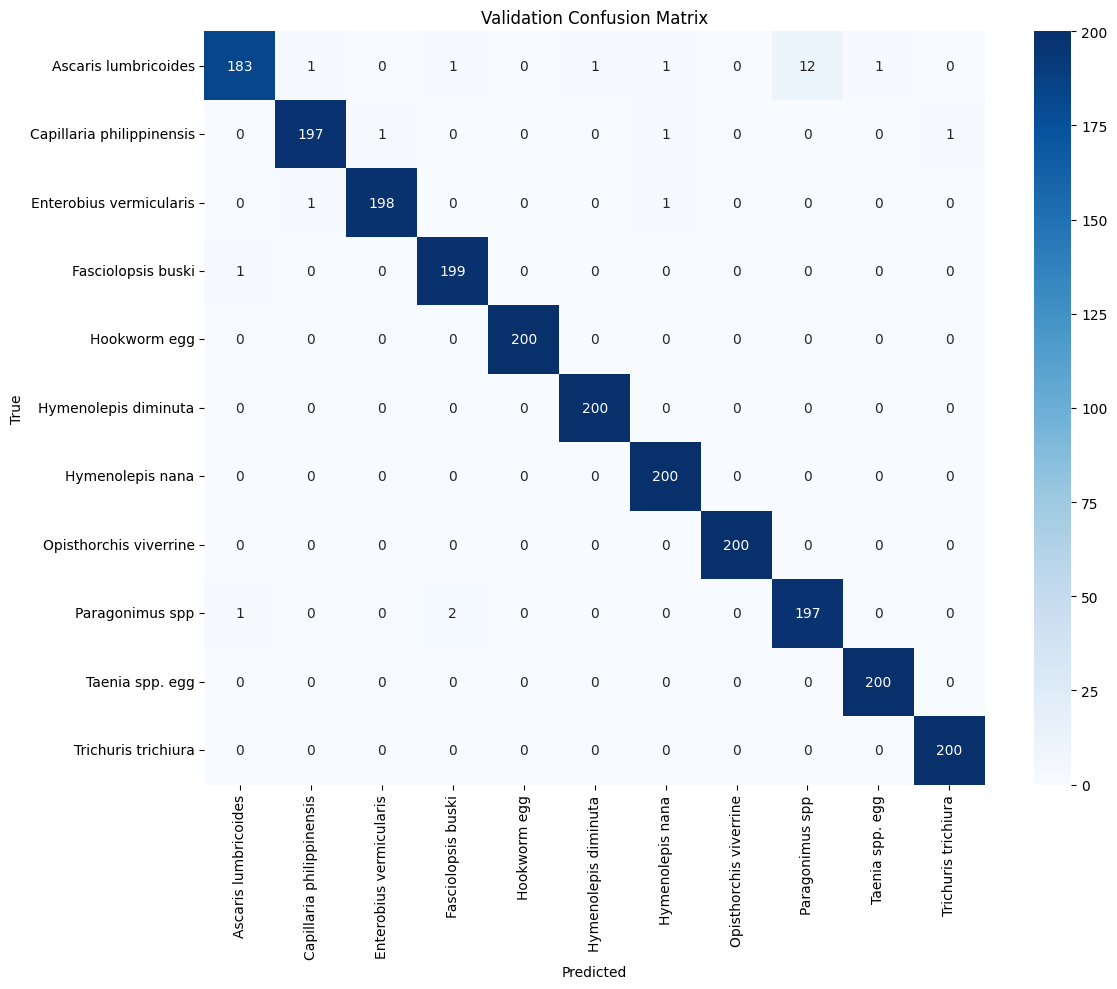

In [ ]:
val_preds = apply_thresholds(val_raw_predictions, best_thresholds)
y_true = [val_ground_truth[f] for f in val_preds.keys()]
y_pred = [val_preds[f] for f in val_preds.keys()]

# ดู per-class F1 → หา class ที่ weak ที่สุด
target_names = [class_names[i] for i in range(NUM_CLASSES)]
if -1 in set(y_true + y_pred):
    target_names = ['no_egg'] + target_names
    labels = [-1] + list(range(NUM_CLASSES))
else:
    labels = list(range(NUM_CLASSES))

print(classification_report(y_true, y_pred, labels=labels, target_names=target_names,
                             zero_division=0, digits=4))

# Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred, labels=labels)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.ylabel('True'); plt.xlabel('Predicted')
plt.title('Validation Confusion Matrix')
plt.tight_layout(); plt.show()

## 8. 📤 Generate Multiple Submissions (4/day budget)

สร้าง **หลาย version** จาก raw predictions ที่ cache ไว้:
1. **Optimal per-class threshold** (จาก val tuning)
2. **Conservative** (+0.05 ทุก class → ตัด false positive)
3. **Aggressive** (-0.05 ทุก class → เพิ่ม recall)
4. **Uniform 0.25** (baseline)

In [ ]:
# 1. ทำ Inference บน Test Set ก่อนสร้าง Submission
SAVE_DIR = DRIVE_BASE
SUBMISSION_ORDER = sorted(os.listdir(TEST_IMG_DIR))
raw_predictions = {}

print("🚀 Running inference on Test Set...")
for i in tqdm(range(0, len(SUBMISSION_ORDER), BATCH), desc='Test inference'):
    batch_files = SUBMISSION_ORDER[i:i+BATCH]
    batch_paths = [str(Path(TEST_IMG_DIR) / f) for f in batch_files]
    results = best_model.predict(source=batch_paths, conf=0.01, iou=0.5, imgsz=640, augment=True, verbose=False)
    for fname, r in zip(batch_files, results):
        if r.boxes is None or len(r.boxes) == 0:
            raw_predictions[fname] = []
        else:
            confs = r.boxes.conf.cpu().numpy()
            classes = r.boxes.cls.cpu().numpy().astype(int)
            raw_predictions[fname] = list(zip(classes.tolist(), confs.tolist()))

def make_submission(raw_preds, thresholds, filename):
    predictions = apply_thresholds(raw_preds, thresholds)
    sub = pd.DataFrame({
        'filename': SUBMISSION_ORDER,
        'label': [predictions.get(f, -1) for f in SUBMISSION_ORDER],
    })
    sub.to_csv(filename, index=False)
    dist = sub['label'].value_counts().sort_index().to_dict()
    print(f'📄 {Path(filename).name}')
    print(f'   Distribution: {dist}')
    return sub

# Variant 1: Optimal
make_submission(raw_predictions, best_thresholds, f'{SAVE_DIR}/sub_v1_optimal.csv')

# Variant 2: Conservative
conservative = {c: min(0.7, v + 0.05) for c, v in best_thresholds.items()}
make_submission(raw_predictions, conservative, f'{SAVE_DIR}/sub_v2_conservative.csv')

# Variant 3: Aggressive
aggressive = {c: max(0.05, v - 0.05) for c, v in best_thresholds.items()}
make_submission(raw_predictions, aggressive, f'{SAVE_DIR}/sub_v3_aggressive.csv')

# Variant 4: Uniform baseline
uniform = {c: 0.25 for c in range(NUM_CLASSES)}
make_submission(raw_predictions, uniform, f'{SAVE_DIR}/sub_v4_uniform.csv')

print('\n✅ All 4 submissions saved to Drive')
print('💡 Submit them in priority order: v1 (optimal) → v3 (aggressive) → v2 → v4')

🚀 Running inference on Test Set...


Test inference: 100%|██████████| 126/126 [03:24<00:00,  1.63s/it]


📄 sub_v1_optimal.csv
   Distribution: {-1: 607, 0: 109, 1: 56, 2: 385, 3: 671, 4: 1, 5: 46, 6: 34, 7: 52, 8: 31, 9: 8, 10: 2}
📄 sub_v2_conservative.csv
   Distribution: {-1: 700, 0: 108, 1: 47, 2: 324, 3: 661, 4: 1, 5: 46, 6: 31, 7: 47, 8: 29, 9: 7, 10: 1}
📄 sub_v3_aggressive.csv
   Distribution: {-1: 479, 0: 111, 1: 61, 2: 470, 3: 682, 4: 2, 5: 46, 6: 41, 7: 68, 8: 31, 9: 9, 10: 2}
📄 sub_v4_uniform.csv
   Distribution: {-1: 842, 0: 102, 1: 34, 2: 245, 3: 638, 5: 43, 6: 28, 7: 37, 8: 25, 9: 7, 10: 1}

✅ All 4 submissions saved to Drive
💡 Submit them in priority order: v1 (optimal) → v3 (aggressive) → v2 → v4


---
# 🆕 Phase 2: Fine-tune ด้วย Mendeley Negative Images

**เป้าหมาย**: เพิ่ม 300 negative images จาก Mendeley (Bangladesh) → สอน model เรื่อง `-1`
**วิธี**: Fine-tune จาก best.pt เดิม (ไม่ train ใหม่จาก scratch)
**เวลา**: ~20-30 นาที (vs train ใหม่ 3 ชม)

**Source**: https://data.mendeley.com/datasets/wbvb4whbks/1

## 9. ดาวน์โหลด Mendeley dataset

**Manual download** (Mendeley ไม่รองรับ direct download ผ่าน wget):
1. ไป https://data.mendeley.com/datasets/wbvb4whbks/1
2. กด **"Download All"** (~50-100 MB)
3. Upload zip ขึ้น Drive ที่: `{DRIVE_BASE}/mendeley_dataset.zip`
4. รันเซลล์ถัดไปเพื่อ extract

In [ ]:
# Extract Mendeley zip
MENDELEY_ZIP = f'{DRIVE_BASE}/mendeley_dataset.zip'
MENDELEY_DIR = '/content/mendeley_data'

os.makedirs(MENDELEY_DIR, exist_ok=True)

if os.path.exists(MENDELEY_ZIP):
    !cd {MENDELEY_DIR} && unzip -oq "{MENDELEY_ZIP}"
    print('✅ Extracted')
    print('\n📁 Folder structure:')
    !find {MENDELEY_DIR} -maxdepth 3 -type d
else:
    print(f'❌ ไม่เจอ {MENDELEY_ZIP}')
    print('   กรุณา upload zip จาก https://data.mendeley.com/datasets/wbvb4whbks/1')

## 10. หา Negative folder + เตรียมเป็น YOLO format

In [ ]:
# Auto-detect negative folder
negative_keywords = ['negative', 'control', 'no_parasite', 'normal']
negative_dir = None

for root, dirs, files in os.walk(MENDELEY_DIR):
    for d in dirs:
        if any(kw in d.lower() for kw in negative_keywords):
            full_path = os.path.join(root, d)
            n_imgs = len([f for f in os.listdir(full_path)
                          if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            if n_imgs > 50:
                negative_dir = full_path
                print(f'✅ พบ Negative folder: {full_path}')
                print(f'   จำนวนภาพ: {n_imgs}')
                break
    if negative_dir:
        break

if not negative_dir:
    print('❌ ไม่พบอัตโนมัติ — ตั้ง path เองหลังดูโครงสร้างจากเซลล์ก่อน')
    print("   ตัวอย่าง: negative_dir = '/content/mendeley_data/Negative_Control'")

In [ ]:
# Copy negative images เข้า train folder + สร้าง empty label files
TRAIN_IMG_DIR = Path(WORK_DIR) / 'images' / 'train'
TRAIN_LBL_DIR = Path(WORK_DIR) / 'labels' / 'train'

n_before = len(list(TRAIN_IMG_DIR.glob('*')))
print(f'Train images ก่อนเพิ่ม: {n_before}')

added = 0
negative_files = sorted([f for f in os.listdir(negative_dir)
                          if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

for fn in tqdm(negative_files, desc='Add negatives'):
    src = Path(negative_dir) / fn
    new_name = f'mendeley_neg_{fn}'
    dst_img = TRAIN_IMG_DIR / new_name
    dst_lbl = TRAIN_LBL_DIR / (Path(new_name).stem + '.txt')

    if dst_img.exists():
        continue

    # Copy image + create empty label = background for YOLO
    shutil.copy(src, dst_img)
    dst_lbl.touch()  # empty file
    added += 1

n_after = len(list(TRAIN_IMG_DIR.glob('*')))
print(f'\n✅ เพิ่ม {added} negative images')
print(f'Train images หลังเพิ่ม: {n_after} (+{n_after-n_before})')

# Verify ดูภาพ 4 ตัวอย่าง
neg_imgs = list(TRAIN_IMG_DIR.glob('mendeley_neg_*'))[:4]
if neg_imgs:
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for ax, p in zip(axes, neg_imgs):
        img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        ax.imshow(img); ax.axis('off'); ax.set_title(p.name[:25])
    plt.tight_layout(); plt.show()

## 11. 🚀 Fine-tune จาก best.pt เดิม

**Key**:
- โหลด `best.pt`
- `epochs=8` พอ — แค่ adapt ให้รู้จัก background
- `lr0=0.0003` ต่ำกว่าเดิม 3 เท่า
- Augmentation อ่อนลง

In [ ]:
# โหลด best.pt จาก training รอบก่อน (Cell [11])
PREV_BEST_PT = 'parasite_runs/yolov8s_fast_pipeline/weights/best.pt'

assert os.path.exists(PREV_BEST_PT), f'❌ ไม่เจอ {PREV_BEST_PT} — รัน training cell [11] ให้เสร็จก่อน'

model_ft = YOLO(PREV_BEST_PT)
print(f'✅ Loaded {PREV_BEST_PT}')

results_ft = model_ft.train(
    data=DATA_YAML,             # yaml เดิม (train folder มี negatives เพิ่มแล้ว)
    epochs=8,                    # 🔥 น้อย เพราะ fine-tune
    imgsz=640,
    batch=32,
    optimizer='AdamW',
    lr0=0.0003,                  # 🔥 ต่ำกว่าเดิม
    lrf=0.01,
    cos_lr=True,

    # Augmentation อ่อนลง
    hsv_h=0.01, hsv_s=0.5, hsv_v=0.3,
    degrees=30,
    translate=0.1, scale=0.3,
    flipud=0.5, fliplr=0.5,
    mosaic=0.3,
    mixup=0.05,
    close_mosaic=2,

    project='parasite_runs',
    name='finetune_with_negatives',
    exist_ok=True, plots=True, save=True,
)

# Save ไป Drive
shutil.copy('parasite_runs/finetune_with_negatives/weights/best.pt',
            f'{DRIVE_BASE}/best_finetuned.pt')
print('\n✅ Fine-tuned model saved')

## 12. Inference + เปรียบเทียบกับ baseline

In [ ]:
# Inference test set ด้วย fine-tuned model
ft_model = YOLO('parasite_runs/finetune_with_negatives/weights/best.pt')

raw_predictions_ft = {}
BATCH = 32

print('🚀 Running inference with fine-tuned model...')
for i in tqdm(range(0, len(SUBMISSION_ORDER), BATCH), desc='Test'):
    batch_files = SUBMISSION_ORDER[i:i+BATCH]
    batch_paths = [str(Path(TEST_IMG_DIR) / f) for f in batch_files]
    results = ft_model.predict(source=batch_paths, conf=0.01, iou=0.5,
                                 imgsz=640, augment=True, verbose=False)
    for fname, r in zip(batch_files, results):
        if r.boxes is None or len(r.boxes) == 0:
            raw_predictions_ft[fname] = []
        else:
            confs = r.boxes.conf.cpu().numpy()
            classes = r.boxes.cls.cpu().numpy().astype(int)
            raw_predictions_ft[fname] = list(zip(classes.tolist(), confs.tolist()))

# Cache
with open(f'{DRIVE_BASE}/raw_predictions_ft.pkl', 'wb') as f:
    pickle.dump(raw_predictions_ft, f)
print(f'\n✅ Cached {len(raw_predictions_ft)} predictions')

In [ ]:
# เปรียบเทียบ baseline vs fine-tuned (ใช้ uniform threshold 0.25)
th_uniform = {c: 0.25 for c in range(NUM_CLASSES)}

pred_baseline = apply_thresholds(raw_predictions, th_uniform)
pred_ft = apply_thresholds(raw_predictions_ft, th_uniform)

print('Baseline distribution:')
print(pd.Series(list(pred_baseline.values())).value_counts().sort_index())
print('\nFine-tuned distribution:')
print(pd.Series(list(pred_ft.values())).value_counts().sort_index())

# Agreement
same = sum(1 for f in pred_baseline if pred_baseline[f] == pred_ft.get(f, -999))
print(f'\nAgreement: {same}/{len(pred_baseline)} ({same/len(pred_baseline)*100:.1f}%)')

# ภาพที่เปลี่ยนเป็น -1 หลัง fine-tune
flipped_to_neg = [f for f in pred_baseline
                   if pred_baseline[f] != -1 and pred_ft.get(f) == -1]
print(f'\n📊 ภาพที่ตอนนี้ predict -1 แทน class: {len(flipped_to_neg)}')
print('   ถ้า public LB ดีขึ้น = test set มีภาพ no-egg จริง')
print('   ถ้า public LB แย่ลง = ภาพเหล่านี้ควรเป็น class จริงๆ')

## 13. Tune threshold + Generate submissions

In [ ]:
# Re-run val inference with fine-tuned model + tune threshold
val_paths = [str(p) for p in (Path(WORK_DIR)/'images'/'val').glob('*') if p.is_file()]

raw_val_ft = {}
for i in tqdm(range(0, len(val_paths), BATCH), desc='Val'):
    chunk = val_paths[i:i+BATCH]
    results = ft_model.predict(source=chunk, conf=0.01, iou=0.5,
                                 imgsz=640, augment=True, verbose=False)
    for p, r in zip(chunk, results):
        fn = Path(p).name
        if r.boxes is None or len(r.boxes) == 0:
            raw_val_ft[fn] = []
        else:
            confs = r.boxes.conf.cpu().numpy()
            classes = r.boxes.cls.cpu().numpy().astype(int)
            raw_val_ft[fn] = list(zip(classes.tolist(), confs.tolist()))

# Greedy per-class tuning
best_th_ft = {c: 0.25 for c in range(NUM_CLASSES)}
for it in range(3):
    for c in range(NUM_CLASSES):
        cur_f1 = evaluate_macro_f1(apply_thresholds(raw_val_ft, best_th_ft), val_ground_truth)
        best_c_th = best_th_ft[c]
        for try_th in np.arange(0.05, 0.65, 0.05):
            test = best_th_ft.copy()
            test[c] = try_th
            f1 = evaluate_macro_f1(apply_thresholds(raw_val_ft, test), val_ground_truth)
            if f1 > cur_f1:
                cur_f1 = f1; best_c_th = try_th
        best_th_ft[c] = best_c_th

final_f1_ft = evaluate_macro_f1(apply_thresholds(raw_val_ft, best_th_ft), val_ground_truth)
print(f'\n✅ Fine-tuned Val Macro F1: {final_f1_ft:.4f}')
print(f'   เทียบ baseline:        {final_f1:.4f}' if 'final_f1' in dir() else '')
print('Per-class thresholds:', {c: round(v,2) for c,v in best_th_ft.items()})

In [ ]:
# Generate 4 fine-tuned submissions
make_submission(raw_predictions_ft, best_th_ft, f'{SAVE_DIR}/sub_ft_v1_optimal.csv')

conservative_ft = {c: min(0.7, v+0.05) for c,v in best_th_ft.items()}
make_submission(raw_predictions_ft, conservative_ft, f'{SAVE_DIR}/sub_ft_v2_conservative.csv')

aggressive_ft = {c: max(0.05, v-0.05) for c,v in best_th_ft.items()}
make_submission(raw_predictions_ft, aggressive_ft, f'{SAVE_DIR}/sub_ft_v3_aggressive.csv')

uniform = {c: 0.25 for c in range(NUM_CLASSES)}
make_submission(raw_predictions_ft, uniform, f'{SAVE_DIR}/sub_ft_v4_uniform.csv')

print('\n✅ Submissions saved with prefix "sub_ft_*"')
print('\n📋 Submit strategy:')
print('   1. ส่ง sub_ft_v1_optimal.csv ก่อน')
print('   2. เทียบกับ sub_v1_optimal.csv (baseline)')
print('   3. ถ้า fine-tuned > baseline → fine-tuning ช่วยจริง')
print('   4. ถ้า baseline > fine-tuned → test ไม่มี -1 เยอะ ใช้ baseline ต่อ')

---
# 🆕 Phase 3: Fine-tune ด้วย AI4NTD KK2.0 P1.5 (Kaggle)

**Source**: https://www.kaggle.com/datasets/peterkward/ai4ntd-p1-5  
**License**: CC BY-SA 4.0 (ฟรี)

## 🎯 เป้าหมาย
เพิ่ม Ascaris/Hookworm/Trichuris จาก domain ใหม่ (Kato-Katz smears) → ช่วย domain shift

## Class mapping
- Ascaris → Chula class 0
- Hookworm (Necator/Ancylostoma) → Chula class 4
- Trichuris → Chula class 10
- **Schistosoma mansoni → -1** (unknown class)

**Run**: หลังจาก Phase 2 (Mendeley) เสร็จและ submit แล้ว

## 14. Setup Kaggle API

**ขั้นตอน:**
1. ไป https://www.kaggle.com/settings/account
2. Section "API" → กด **"Create New Token"** → ดาวน์โหลด `kaggle.json`
3. Upload ไฟล์ `kaggle.json` ใน cell ถัดไป

In [ ]:
!pip install -q kaggle

from google.colab import files
import os

if not os.path.exists('/root/.kaggle/kaggle.json'):
    print('📤 Upload kaggle.json (จาก Kaggle Settings → API → Create New Token)')
    uploaded = files.upload()
    !mkdir -p /root/.kaggle
    !mv kaggle.json /root/.kaggle/
    !chmod 600 /root/.kaggle/kaggle.json
    print('✅ Kaggle API พร้อมใช้')
else:
    print('✅ Kaggle API พร้อมใช้แล้ว')

!kaggle datasets list -s parasite | head -3

## 15. Download AI4NTD P1.5

In [ ]:
AI4NTD_DIR = '/content/ai4ntd_data'
os.makedirs(AI4NTD_DIR, exist_ok=True)

# Download (~2-5 GB ใช้เวลาสักครู่)
!cd {AI4NTD_DIR} && kaggle datasets download -d peterkward/ai4ntd-p1-5 --unzip

print('\n📁 Top-level structure:')
!find {AI4NTD_DIR} -maxdepth 3 -type d | head -20

print('\n📄 Files:')
!ls -la {AI4NTD_DIR} | head -10

## 16. ตรวจสอบ format + หา annotation file

In [ ]:
from pathlib import Path

# Auto-detect format (COCO JSON / YOLO txt / XML)
json_files = []
txt_label_dirs = []

for root, dirs, files in os.walk(AI4NTD_DIR):
    for f in files:
        if f.endswith('.json') and any(k in f.lower() for k in ['coco','annotation','label','train','test','val']):
            json_files.append(os.path.join(root, f))
    if Path(root).name.lower() in ['labels', 'label']:
        txt_files = [f for f in files if f.endswith('.txt')]
        if len(txt_files) > 10:
            txt_label_dirs.append(root)

print(f'COCO JSON files: {len(json_files)}')
for f in json_files[:10]: print(f'  {f}')

print(f'\nYOLO label dirs: {len(txt_label_dirs)}')
for d in txt_label_dirs[:5]: print(f'  {d}')

In [ ]:
# ดู content ของ JSON หลัก (ใหญ่ที่สุด)
if json_files:
    main_json = max(json_files, key=lambda f: os.path.getsize(f))
    print(f'Main annotation: {main_json}')
    print(f'Size: {os.path.getsize(main_json)/1e6:.1f} MB\n')

    with open(main_json) as f:
        coco_data = json.load(f)

    print(f'Keys: {list(coco_data.keys())}')

    if 'categories' in coco_data:
        print(f'\nCategories ({len(coco_data["categories"])}):')
        for c in coco_data['categories']:
            print(f"  id={c.get('id')}, name='{c.get('name')}'")

    if 'images' in coco_data:
        print(f'\nImages: {len(coco_data["images"])}')
        print(f'Sample: {coco_data["images"][0]}')

    if 'annotations' in coco_data:
        print(f'\nAnnotations: {len(coco_data["annotations"])}')
        print(f'Sample: {coco_data["annotations"][0]}')
else:
    print('❌ ไม่เจอ COCO JSON — เช็คโครงสร้างจากเซลล์ก่อนแล้วแก้เอง')

## 17. Class mapping: AI4NTD → Chula

In [ ]:
# Auto-map class names → Chula class IDs
AI4NTD_TO_CHULA = {}  # category_id → chula_class_id (-1 = drop เป็น background)

for cat in coco_data.get('categories', []):
    name_lower = cat['name'].lower()
    cid = cat['id']

    if 'ascaris' in name_lower:
        AI4NTD_TO_CHULA[cid] = 0
        target = 'Chula 0 (Ascaris)'
    elif any(k in name_lower for k in ['hookworm', 'necator', 'ancylostoma']):
        AI4NTD_TO_CHULA[cid] = 4
        target = 'Chula 4 (Hookworm)'
    elif 'trichuris' in name_lower:
        AI4NTD_TO_CHULA[cid] = 10
        target = 'Chula 10 (Trichuris)'
    elif any(k in name_lower for k in ['schistosoma', 'mansoni', 'sch']):
        AI4NTD_TO_CHULA[cid] = -1
        target = '-1 (drop, unknown)'
    else:
        AI4NTD_TO_CHULA[cid] = -1
        target = '-1 (unknown)'

    print(f"  '{cat['name']}' (id={cid}) → {target}")

n_mapped = sum(1 for v in AI4NTD_TO_CHULA.values() if v >= 0)
n_dropped = sum(1 for v in AI4NTD_TO_CHULA.values() if v == -1)
print(f'\n📊 Mapped to Chula: {n_mapped}, Dropped to -1: {n_dropped}')

## 18. แปลง AI4NTD → YOLO format + เพิ่มเข้า train

In [ ]:
from collections import defaultdict, Counter
import shutil, cv2, random
from tqdm import tqdm

TRAIN_IMG_DIR = Path(WORK_DIR) / 'images' / 'train'
TRAIN_LBL_DIR = Path(WORK_DIR) / 'labels' / 'train'

n_before = len(list(TRAIN_IMG_DIR.glob('*')))
print(f'Train images ก่อนเพิ่ม AI4NTD: {n_before}')

# Group annotations by image_id
img_id_to_anns = defaultdict(list)
for ann in coco_data.get('annotations', []):
    img_id_to_anns[ann['image_id']].append(ann)

# Find image folders
image_folders = []
for root, dirs, files in os.walk(AI4NTD_DIR):
    img_files = [f for f in files if f.lower().endswith(('.jpg','.jpeg','.png'))]
    if len(img_files) > 50:
        image_folders.append((root, len(img_files)))

print(f'\nImage folders:')
for f, n in image_folders[:5]:
    print(f'  {f}: {n} images')

main_img_dir = max(image_folders, key=lambda x: x[1])[0]
print(f'\nUsing main folder: {main_img_dir}')

In [ ]:
# Convert COCO → YOLO + map classes
added = 0
added_per_class = Counter()
skipped_no_image = 0

for img_info in tqdm(coco_data['images'], desc='Convert AI4NTD'):
    fn = img_info['file_name']
    W, H = img_info.get('width'), img_info.get('height')

    src_img = Path(main_img_dir) / fn
    if not src_img.exists():
        # search in subfolders
        matches = list(Path(AI4NTD_DIR).rglob(Path(fn).name))
        if not matches:
            skipped_no_image += 1
            continue
        src_img = matches[0]

    if not W or not H:
        img = cv2.imread(str(src_img))
        if img is None: continue
        H, W = img.shape[:2]

    # แปลง annotations + map classes
    anns = img_id_to_anns.get(img_info['id'], [])
    yolo_lines = []

    for ann in anns:
        chula_cls = AI4NTD_TO_CHULA.get(ann['category_id'], -1)
        if chula_cls == -1:
            continue  # skip unknown classes

        x, y, w, h = ann['bbox']
        xc = max(0, min(1, (x + w/2) / W))
        yc = max(0, min(1, (y + h/2) / H))
        nw = max(0, min(1, w / W))
        nh = max(0, min(1, h / H))
        yolo_lines.append(f'{chula_cls} {xc:.6f} {yc:.6f} {nw:.6f} {nh:.6f}')
        added_per_class[chula_cls] += 1

    # ภาพไหนไม่มี mapped annotation → empty label = -1 (เช่น Schisto-only)
    if not yolo_lines:
        added_per_class[-1] += 1

    # Copy ภาพ + label
    new_name = f'ai4ntd_{Path(fn).stem}.jpg'
    dst_img = TRAIN_IMG_DIR / new_name
    dst_lbl = TRAIN_LBL_DIR / (Path(new_name).stem + '.txt')

    if dst_img.exists():
        continue

    shutil.copy(src_img, dst_img)
    with open(dst_lbl, 'w') as f:
        f.write('\n'.join(yolo_lines))

    added += 1

n_after = len(list(TRAIN_IMG_DIR.glob('*')))

print(f'\n✅ เพิ่ม {added} ภาพจาก AI4NTD')
print(f'   Train images: {n_before} → {n_after} (+{n_after-n_before})')
print(f'   Skipped (no image): {skipped_no_image}')

print(f'\n📊 จำนวน annotations เพิ่ม:')
for cls, cnt in sorted(added_per_class.items()):
    if cls == -1:
        print(f'   empty (= -1)            : +{cnt}')
    else:
        names = ['Ascaris','Cap','Ent','Fas','Hook','HymD','HymN','Opi','Par','Tae','Tri']
        print(f'   class {cls} ({names[cls]:<8s})    : +{cnt}')

In [ ]:
# Verify: ดูตัวอย่าง 6 ภาพพร้อม bbox
import matplotlib.pyplot as plt

ai4ntd_imgs = list(TRAIN_IMG_DIR.glob('ai4ntd_*'))
samples = random.sample(ai4ntd_imgs, min(6, len(ai4ntd_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()
names_short = ['Asc','Cap','Ent','Fas','Hook','HD','HN','Opi','Par','Tae','Tri']

for ax, p in zip(axes, samples):
    img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
    H, W = img.shape[:2]

    lbl = TRAIN_LBL_DIR / (p.stem + '.txt')
    if lbl.exists() and lbl.stat().st_size > 0:
        with open(lbl) as f:
            for line in f:
                if not line.strip(): continue
                c, xc, yc, nw, nh = map(float, line.split())
                x1 = int((xc-nw/2)*W); y1 = int((yc-nh/2)*H)
                x2 = int((xc+nw/2)*W); y2 = int((yc+nh/2)*H)
                cv2.rectangle(img, (x1,y1), (x2,y2), (255,0,0), 4)
                cv2.putText(img, names_short[int(c)], (x1, y1-10),
                            cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255,0,0), 2)
        title = f'{p.name[:25]}'
    else:
        title = f'{p.name[:25]}\n(empty = -1)'

    ax.imshow(img); ax.axis('off'); ax.set_title(title, fontsize=10)

plt.tight_layout(); plt.show()

## 19. 🚀 Fine-tune ต่อจาก Mendeley

โหลด `best.pt` จาก Phase 2 (Mendeley) → train ต่อด้วย AI4NTD

In [ ]:
from ultralytics import YOLO

# โหลด best จาก Mendeley fine-tune (หรือ baseline ถ้าข้าม Mendeley)
CHECKPOINT_OPTIONS = [
    'parasite_runs/finetune_with_mendeley/weights/best.pt',  # ★ หลัง Mendeley
    'parasite_runs/yolov8s_fast_pipeline/weights/best.pt',   # baseline
    f'{DRIVE_BASE}/best_finetuned.pt',                       # backup จาก Drive
]

AI4NTD_START_PT = None
for p in CHECKPOINT_OPTIONS:
    if os.path.exists(p):
        AI4NTD_START_PT = p
        break

assert AI4NTD_START_PT, '❌ ไม่เจอ checkpoint'
print(f'✅ Will fine-tune from: {AI4NTD_START_PT}')

model_ai4ntd = YOLO(AI4NTD_START_PT)

results_ai4ntd = model_ai4ntd.train(
    data=DATA_YAML,
    epochs=10,                     # นานกว่า Mendeley นิดเพราะข้อมูลใหม่เยอะ
    imgsz=640,
    batch=32,
    optimizer='AdamW',
    lr0=0.0003,
    lrf=0.01,
    cos_lr=True,

    # Augmentation moderate (Kato-Katz domain ต่าง)
    hsv_h=0.015, hsv_s=0.6, hsv_v=0.4,
    degrees=90,
    translate=0.1, scale=0.4,
    flipud=0.5, fliplr=0.5,
    mosaic=0.5,
    mixup=0.1,
    close_mosaic=3,

    project='parasite_runs',
    name='finetune_with_ai4ntd',
    exist_ok=True, plots=True, save=True,
)

shutil.copy('parasite_runs/finetune_with_ai4ntd/weights/best.pt',
            f'{DRIVE_BASE}/best_ai4ntd.pt')
print('\n✅ Saved best_ai4ntd.pt to Drive')

## 20. Inference + Generate submissions

In [ ]:
import pickle

ai4ntd_model = YOLO('parasite_runs/finetune_with_ai4ntd/weights/best.pt')

raw_predictions_ai4ntd = {}
BATCH = 32

print('🚀 Test inference...')
for i in tqdm(range(0, len(SUBMISSION_ORDER), BATCH), desc='Test'):
    batch_files = SUBMISSION_ORDER[i:i+BATCH]
    batch_paths = [str(Path(TEST_IMG_DIR) / f) for f in batch_files]
    results = ai4ntd_model.predict(source=batch_paths, conf=0.01, iou=0.5,
                                     imgsz=640, augment=True, verbose=False)
    for fname, r in zip(batch_files, results):
        if r.boxes is None or len(r.boxes) == 0:
            raw_predictions_ai4ntd[fname] = []
        else:
            confs = r.boxes.conf.cpu().numpy()
            classes = r.boxes.cls.cpu().numpy().astype(int)
            raw_predictions_ai4ntd[fname] = list(zip(classes.tolist(), confs.tolist()))

with open(f'{DRIVE_BASE}/raw_predictions_ai4ntd.pkl', 'wb') as f:
    pickle.dump(raw_predictions_ai4ntd, f)
print(f'\n✅ Cached {len(raw_predictions_ai4ntd)} predictions')

In [ ]:
# Re-tune threshold บน val
import numpy as np

val_paths = [str(p) for p in (Path(WORK_DIR)/'images'/'val').glob('*') if p.is_file()]
raw_val_ai4ntd = {}
for i in tqdm(range(0, len(val_paths), BATCH), desc='Val'):
    chunk = val_paths[i:i+BATCH]
    results = ai4ntd_model.predict(source=chunk, conf=0.01, iou=0.5,
                                     imgsz=640, augment=True, verbose=False)
    for p, r in zip(chunk, results):
        fn = Path(p).name
        if r.boxes is None or len(r.boxes) == 0:
            raw_val_ai4ntd[fn] = []
        else:
            confs = r.boxes.conf.cpu().numpy()
            classes = r.boxes.cls.cpu().numpy().astype(int)
            raw_val_ai4ntd[fn] = list(zip(classes.tolist(), confs.tolist()))

# Greedy per-class tuning
best_th_ai = {c: 0.25 for c in range(NUM_CLASSES)}
for it in range(3):
    for c in range(NUM_CLASSES):
        cur_f1 = evaluate_macro_f1(apply_thresholds(raw_val_ai4ntd, best_th_ai), val_ground_truth)
        best_c_th = best_th_ai[c]
        for try_th in np.arange(0.05, 0.65, 0.05):
            test = best_th_ai.copy()
            test[c] = try_th
            f1 = evaluate_macro_f1(apply_thresholds(raw_val_ai4ntd, test), val_ground_truth)
            if f1 > cur_f1:
                cur_f1 = f1; best_c_th = try_th
        best_th_ai[c] = best_c_th

final_f1_ai = evaluate_macro_f1(apply_thresholds(raw_val_ai4ntd, best_th_ai), val_ground_truth)
print(f'\n✅ Val Macro F1 (after AI4NTD): {final_f1_ai:.4f}')
print('Thresholds:', {c: round(v,2) for c,v in best_th_ai.items()})

In [ ]:
# Generate submissions ใหม่
make_submission(raw_predictions_ai4ntd, best_th_ai, f'{SAVE_DIR}/sub_ai4ntd_v1_optimal.csv')
make_submission(raw_predictions_ai4ntd, {c: min(0.7,v+0.05) for c,v in best_th_ai.items()}, f'{SAVE_DIR}/sub_ai4ntd_v2_conservative.csv')
make_submission(raw_predictions_ai4ntd, {c: max(0.05,v-0.05) for c,v in best_th_ai.items()}, f'{SAVE_DIR}/sub_ai4ntd_v3_aggressive.csv')
make_submission(raw_predictions_ai4ntd, {c: 0.25 for c in range(NUM_CLASSES)}, f'{SAVE_DIR}/sub_ai4ntd_v4_uniform.csv')

print('\n✅ Submissions saved with prefix "sub_ai4ntd_*"')
print('\n📊 Compare on public LB:')
print('   1. sub_v1_optimal.csv         (baseline เดิม)')
print('   2. sub_ft_v1_optimal.csv      (หลัง Mendeley)')
print('   3. sub_ai4ntd_v1_optimal.csv  (หลัง Mendeley + AI4NTD)')
print('\n💡 Submit ทีละ version แล้วดู LB → ใช้ version ที่ดีที่สุด')

## 21. 🎯 Strategy Summary หลังจบ 3 Phases

ตอนนี้คุณมี models 3 ตัวบน Drive:
- `best_baseline.pt` — Chula 11,000 images
- `best_finetuned.pt` — + Mendeley (background + unknown egg)
- `best_ai4ntd.pt` — + AI4NTD (Ascaris/Hookworm/Trichuris จาก domain ใหม่)

### ตัดสินใจจาก Public LB

| Pattern | สรุป | Action |
|---|---|---|
| baseline สูงสุด | data ใหม่ทำ model สับสน | ใช้ baseline ทำ pseudo-labeling |
| Mendeley สูงสุด | test มี -1 เยอะจริง | เพิ่ม Mendeley อีก / ParasitoBank |
| AI4NTD สูงสุด | domain shift = ปัญหาหลัก | เพิ่ม external data ของ 3 classes อื่น |
| 3 versions ใกล้กัน | ทุกอย่างช่วยได้บ้าง | **Ensemble ของทั้ง 3 → WBF** |

### Next steps ที่เป็นไปได้
1. **Pseudo-labeling**: predict test → confident ones → add → retrain
2. **Ensemble**: รวม predictions ของ 3 models ด้วย Weighted Box Fusion
3. **เพิ่ม ParasitoBank**: 779 ภาพ smartphone capture → ตรง "different conditions"
4. **Larger model**: ลอง YOLOv8m หรือ YOLOv8l (ถ้ามีเวลา)